In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data as get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.statistics_test as st

from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))

from pathlib import Path
#OUT = Path("figures"); OUT.mkdir(exist_ok=True)
import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,   
})

DATA_ROOT = 'DATAPATH'  
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

animal_ids = st.animal_labels(datapaths)

c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
def analyze_data_common(datapath, reference, maps, analysis_type, method='subspace', compute_day11_12=False, 
                        transients=False, dim_red=False, max_dim=4, standardize='stand'):
    def get_analysis_function(analysis_type):
        if analysis_type == 'population_geometry':
            return analysis.populationgeometry, analysis.populationgeometry_context
        elif analysis_type == 'topology':
            return analysis.topology_analysis, analysis.topology_analysis_context

    analysis_func, context_func = get_analysis_function(analysis_type)

    def apply_analysis(func, *args):
        if analysis_type == 'population_geometry':
            return func(*args, method=method)
        else:
            return func(*args, max_dim=max_dim)

    hists = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference=reference, maps=maps, 
                                                 reference_type='no_reference', hist='hist', transients=transients, 
                                                 dim_red=dim_red, standardize=standardize, remove_day_inactive=False)
    g = apply_analysis(analysis_func, hists)
    hists_2 = analysis.sort_maps_from_reference_AK(datapath, 'Context2', reference=reference, maps=maps, 
                                                   reference_type='no_reference', hist='hist', transients=transients,
                                                     dim_red=dim_red, standardize=standardize, remove_day_inactive=False)
    g_2 = apply_analysis(analysis_func, hists_2)

    global_seeds = [1,2,3,4,5]
    simu_g_list = []
    for seed in global_seeds:
        simu_drift = analysis.simulate_drift(datapath, session='0', Context='Context1', days=len(maps)+1, drift_type='circular', 
                                             dim_red=dim_red, standardize=standardize, odd_even=True, global_seed=seed, 
                                             active_days=[reference]+maps, remove_day_inactive=True,
                                             max_remap_prob=0.3, amplitude_drift_prob=0.3, amplitude_change_scale=0.5)
        simu_g = apply_analysis(analysis_func, simu_drift['maps'])
        simu_g_list.append(simu_g)
    simu_g_array = np.array(simu_g_list)
    simu_g = np.mean(simu_g_array, axis=0)

    hist_odd, hist_even = analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context1', maps=maps, 
                                                                                  transients=transients, dim_red=dim_red, standardize=standardize, 
                                                                                  remove_day_inactive=False)
    g_odd_even1 = apply_analysis(context_func, hist_odd, hist_even)
    hist_odd, hist_even = analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context2', maps=maps, transients=transients, dim_red=dim_red, standardize=standardize, remove_day_inactive=False)
    g_odd_even2 = apply_analysis(context_func, hist_odd, hist_even)

    if analysis_type == 'population_geometry':              
        shuff1, shuff2 = analysis.shuffle_two_sessions_hist(datapath, '0', '19', 'Context1', dim_red=dim_red, remove_inactive=[reference]+maps, 
                                                            standardize=standardize, remove_day_inactive=False)
        shuff1_con2, shuff2_con2 = analysis.shuffle_two_sessions_hist(datapath, '0', '19', 'Context2', dim_red=dim_red, remove_inactive=[reference]+maps, 
                                                                      standardize=standardize, remove_day_inactive=False)
        g_shuff1 = apply_analysis(context_func, [shuff1], [shuff2])
        g_shuff2 = apply_analysis(context_func, [shuff1_con2], [shuff2_con2])
        
        g = (g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
        g_2 = (g_2 - np.mean(g_odd_even2)) / (np.mean(g_shuff2) - np.mean(g_odd_even2))
        simu_g = (simu_g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
    else:
        g = g-g_odd_even1
        g_2 = g_2-g_odd_even2
        simu_g = simu_g-g_odd_even1

    if compute_day11_12:
        hists_day11 = [h for h, m in zip(hists, maps) if m == '17']
        hists_day12 = [h for h, m in zip(hists, maps) if m == '19']
        hists_2_day12 = [h for h, m in zip(hists_2, maps) if m == '19']

        g_day11_12_context1 = apply_analysis(context_func, hists_day11, hists_day12)
        g_day12_contexts = apply_analysis(context_func, hists_day12, hists_2_day12)

        if analysis_type == 'population_geometry':
            hist_odd_1, hist_even_1 = analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context1', maps=['12'], 
                                                                                          transients=transients, dim_red=dim_red, 
                                                                                          standardize=standardize, remove_day_inactive=False)
            g_odd_even_1 = apply_analysis(context_func, hist_odd_1, hist_even_1)
            g_shuff_11_12 = apply_analysis(context_func, [shuff2], [shuff2_con2])

            g_day12_contexts_norm = (g_day12_contexts - g_odd_even_1) / (np.mean(g_shuff_11_12) - g_odd_even_1)
            g_day11_12_context1_norm = (g_day11_12_context1 - g_odd_even_1) / (np.mean(g_shuff_11_12) - g_odd_even_1)
        else:
            g_day12_contexts_norm = g_day12_contexts
            g_day11_12_context1_norm = g_day11_12_context1

        return g, g_2, simu_g, g_day12_contexts_norm, g_day11_12_context1_norm
    else:
        return g, g_2, simu_g


def collect_data(datapaths, reference, maps, analysis_type, method='subspace', compute_day11_12=False, 
                 transients=False, dim_red=False, max_dim=4, standardize='stand'):
    all_data = []
    for datapath in datapaths:
        data = analyze_data_common(datapath, reference, maps, analysis_type, method=method, compute_day11_12=compute_day11_12, 
                                   transients=transients, dim_red=dim_red, max_dim=max_dim, standardize=standardize)
        all_data.append(data)
    return all_data

if __name__ == "__main__":
    transients = False
    dim_red = False
    max_dim = 4

    reference = '0'
    maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
    forward_data_pop_geometry_angles = collect_data(datapaths, reference, maps, 'population_geometry', method='angles', 
                                                    compute_day11_12=True, transients=transients, dim_red=dim_red, standardize='stand')


C:\Users\oles\AppData\Local\Temp\ipykernel_25136\3158430595.py:14: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


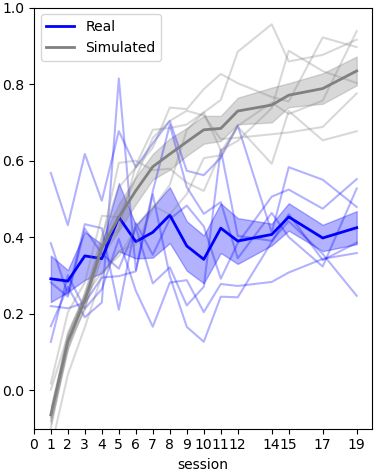

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.3844,0.2508,0.4341,0.4236,0.2105,0.4368,0.3542,0.4477,0.4827,0.4284,0.2916,0.3845,0.5061,0.5245,0.4746,0.5518
51004,0.2203,0.2146,0.2292,0.2949,0.2985,0.3109,0.5122,0.2987,0.1660,0.1270,0.2448,0.2432,0.3878,0.4606,0.3403,0.3857
51007,0.5679,0.4316,0.6175,0.4954,0.6772,0.5830,0.6453,0.7040,0.5736,0.5621,0.6076,0.6919,0.4123,0.5829,0.5503,0.4791
63,0.1676,0.2705,0.1912,0.2295,0.8147,0.3145,0.5202,0.6935,0.5308,0.4612,0.4918,0.3451,0.4634,0.4004,0.3236,0.5273
64,0.2819,0.2449,0.4222,0.3570,0.3180,0.4255,0.2796,0.3215,0.2220,0.2707,0.6289,0.4036,0.3907,0.4420,0.3562,0.2471
65,0.1268,0.3008,0.2137,0.2647,0.3957,0.2603,0.1664,0.2816,0.2880,0.2045,0.2779,0.2728,0.2834,0.3079,0.3435,0.3588


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-0.0981,0.1225,0.2105,0.3912,0.5943,0.6000,0.5751,0.5789,0.5426,0.5209,0.6218,0.6911,0.7515,0.7220,0.7568,0.9382
51004,-0.0799,0.1072,0.2527,0.3754,0.4206,0.5877,0.6807,0.6851,0.6944,0.7261,0.7586,0.8845,0.9563,0.8591,0.8764,0.9159
51007,0.0017,0.1435,0.2521,0.4017,0.5302,0.5820,0.6336,0.7387,0.7346,0.7868,0.8266,0.8023,0.7664,0.7546,0.9219,0.8965
63,-0.1541,0.0414,0.1653,0.2997,0.3643,0.3810,0.4741,0.5368,0.6803,0.7259,0.6272,0.6518,0.7372,0.8872,0.8338,0.8027
64,0.0182,0.2037,0.2822,0.4561,0.4523,0.5553,0.6595,0.7039,0.7304,0.7178,0.6564,0.6600,0.6690,0.6737,0.6882,0.7757
65,-0.0699,0.1501,0.2455,0.3091,0.3509,0.4238,0.4827,0.4597,0.5129,0.6065,0.6141,0.6882,0.5919,0.7295,0.6531,0.6769


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,4.038007,15,75,0.269200,33.433048,4.244521e-27,2.363429e-07,0.621616,0.218161
1,condition,1.198404,1,5,1.198404,15.441219,1.107551e-02,1.107551e-02,0.327757,1.000000
2,time * condition,2.235321,15,75,0.149021,17.639676,8.823681e-19,3.325580e-05,0.476280,0.201289


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,Real,Simulated,t-test,6.2010,0.0016,0.0255,*,2.5315,Cohen's d,0.2915,-0.0637,0.3552,0.1403,6,True,0.5095
1,d2,Real,Simulated,t-test,4.3607,0.0073,0.1166,,1.7803,Cohen's d,0.2855,0.1281,0.1575,0.0885,6,True,0.8988
2,d3,Real,Simulated,t-test,1.8151,0.1292,1.0000,,0.7410,Cohen's d,0.3513,0.2347,0.1166,0.1573,6,True,0.4090
3,d4,Real,Simulated,t-test,-0.9122,0.4035,1.0000,,-0.3724,Cohen's d,0.3442,0.3722,-0.0280,0.0753,6,True,0.2727
4,d5,Real,Simulated,t-test,0.0028,0.9978,1.0000,,0.0012,Cohen's d,0.4524,0.4521,0.0003,0.2852,6,True,0.9302
5,d6,Real,Simulated,t-test,-3.4416,0.0184,0.2945,,-1.4050,Cohen's d,0.3885,0.5216,-0.1331,0.0948,6,True,0.8977
6,d7,Real,Simulated,t-test,-2.4408,0.0586,0.9375,,-0.9965,Cohen's d,0.4130,0.5843,-0.1713,0.1719,6,True,0.5765
7,d8,Real,Simulated,t-test,-1.8698,0.1204,1.0000,,-0.7633,Cohen's d,0.4578,0.6172,-0.1594,0.2088,6,True,0.6059
8,d9,Real,Simulated,t-test,-3.3641,0.0200,0.3203,,-1.3734,Cohen's d,0.3772,0.6492,-0.2720,0.1981,6,True,0.1487
9,d10,Real,Simulated,t-test,-4.5957,0.0059,0.0938,,-1.8762,Cohen's d,0.3423,0.6807,-0.3384,0.1803,6,True,0.9739


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.3844,0.2508,0.4341,0.4236,0.2105,0.4368,0.3542,0.4477,0.4827,0.4284,0.2916,0.3845,0.5061,0.5245,0.4746,0.5518
51004,0.2203,0.2146,0.2292,0.2949,0.2985,0.3109,0.5122,0.2987,0.1660,0.1270,0.2448,0.2432,0.3878,0.4606,0.3403,0.3857
51007,0.5679,0.4316,0.6175,0.4954,0.6772,0.5830,0.6453,0.7040,0.5736,0.5621,0.6076,0.6919,0.4123,0.5829,0.5503,0.4791
63,0.1676,0.2705,0.1912,0.2295,0.8147,0.3145,0.5202,0.6935,0.5308,0.4612,0.4918,0.3451,0.4634,0.4004,0.3236,0.5273
64,0.2819,0.2449,0.4222,0.3570,0.3180,0.4255,0.2796,0.3215,0.2220,0.2707,0.6289,0.4036,0.3907,0.4420,0.3562,0.2471
65,0.1268,0.3008,0.2137,0.2647,0.3957,0.2603,0.1664,0.2816,0.2880,0.2045,0.2779,0.2728,0.2834,0.3079,0.3435,0.3588


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.253710,15,0.016914,1.475306,0.136605,0.122709,0.208599
1,Error,0.859855,75,0.011465,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-0.0981,0.1225,0.2105,0.3912,0.5943,0.6000,0.5751,0.5789,0.5426,0.5209,0.6218,0.6911,0.7515,0.7220,0.7568,0.9382
51004,-0.0799,0.1072,0.2527,0.3754,0.4206,0.5877,0.6807,0.6851,0.6944,0.7261,0.7586,0.8845,0.9563,0.8591,0.8764,0.9159
51007,0.0017,0.1435,0.2521,0.4017,0.5302,0.5820,0.6336,0.7387,0.7346,0.7868,0.8266,0.8023,0.7664,0.7546,0.9219,0.8965
63,-0.1541,0.0414,0.1653,0.2997,0.3643,0.3810,0.4741,0.5368,0.6803,0.7259,0.6272,0.6518,0.7372,0.8872,0.8338,0.8027
64,0.0182,0.2037,0.2822,0.4561,0.4523,0.5553,0.6595,0.7039,0.7304,0.7178,0.6564,0.6600,0.6690,0.6737,0.6882,0.7757
65,-0.0699,0.1501,0.2455,0.3091,0.3509,0.4238,0.4827,0.4597,0.5129,0.6065,0.6141,0.6882,0.5919,0.7295,0.6531,0.6769


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,6.019618,15,0.401308,79.699261,9.419049e-40,0.903341,0.240053
1,Error,0.377646,75,0.005035,NaN,NaN,NaN,NaN


In [ ]:
day_cols_fwd = st.day_labels(maps)

# Forward: real vs simulated
novel = np.vstack([data[1] for data in forward_data_pop_geometry_angles])
simu = np.vstack([data[2] for data in forward_data_pop_geometry_angles])

print_large('\n' + '='*50)
print_large('Forward: Real vs Simulated')
print_large('='*50)
fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_average_geometry([novel, simu], maps, directions=[True, True], 
                           colors=['b', 'gray'], labels=['Real', 'Simulated'], 
                           plot_individual=True, ylim=[-0.1, 1], ax=ax)
fig.tight_layout()
plt.show()

print_large('\nTWO-WAY REPEATED ANOVA: Real vs Simulated')
anova = st.repeated_measures_anova_general(
    [novel, simu], row_labels=animal_ids, col_labels=day_cols_fwd,
    condition_labels=['Real', 'Simulated'],
    title='Novel edge angles, forward (vs d0): real vs simulated')
display(anova[0])
display(anova[1])

print_large('RM ANOVA: Real (forward)')
display(st.repeated_measures_anova_single_condition(
    novel, row_labels=animal_ids, col_labels=day_cols_fwd,
    condition_label='Real', title='Novel edge angles, forward (vs d0): real'))
print_large('RM ANOVA: Simulated (forward)')
display(st.repeated_measures_anova_single_condition(
    simu, row_labels=animal_ids, col_labels=day_cols_fwd,
    condition_label='Simulated', title='Novel edge angles, forward (vs d0): simulated'))